# 03 — Mamba SSM (Colab / A100) · TBM-selected features · WFO · Full Backtest

**Self-contained.** Paste into Google Colab, select an **A100 GPU** runtime
(`Runtime → Change runtime type → A100`), and run all cells top-to-bottom.

This trains a Mamba state-space sequence classifier to produce `P(Up)` per bar,
then runs the **same ATR-bracket grid-search backtester used by the LGBM agent**,
so the artifacts (equity curve, Sharpe, drawdown, monthly returns, win-rate,
trade log, feature importance) are **directly comparable** to the other models.

---

## Files to upload

Drag these **3 parquet files** into the Colab file browser (left panel, into `/content/`),
**or** put them in a Google Drive folder and set `USE_DRIVE = True` below.

| file | size | why it's needed |
|------|------|-----------------|
| `BTCUSDT_1h_features.parquet`     | ~105 MB | V1 feature bank + `close`, `atr_14_pct`, directional `label` |
| `BTCUSDT_1h_v4_features.parquet`  | ~17 MB  | V4 microstructure / fracdiff / Hurst features |
| `BTCUSDT_1h.parquet`              | ~3 MB   | raw OHLCV — supplies `high`/`low` for TBM labels & backtest |

> The big one (`BTCUSDT_1h_features.parquet`) is slow to drag-upload; using
> Google Drive (`USE_DRIVE = True`) is recommended.

**Outputs** (zipped & auto-downloaded at the end): trained model `.pt`,
`results.json`, and all PNG figures.


## 0 · Environment

In [5]:
# Colab already ships torch + sklearn + matplotlib. lightgbm is only needed if you
# re-run the (optional) Boruta feature selection; the validated feature set is baked in.
!pip -q install lightgbm 2>/dev/null
import torch
print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | CUDA available: True
GPU: Tesla T4


In [6]:
import json, math, time, warnings, io, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1 · Configuration

In [7]:
# ── Data source ────────────────────────────────────────────────────────────
USE_DRIVE = True                      # True → mount Google Drive
DRIVE_DIR = '/content/drive/MyDrive/hmats_data'   # folder holding the 3 parquets
LOCAL_DIR = '/content'                  # where drag-uploaded files land

def _repo_root():
    q=Path.cwd()
    while q!=q.parent:
        if (q/'pyproject.toml').exists(): return q
        q=q.parent
    return None
_RR=_repo_root()
ARTS_DIR = (_RR/'artifacts'/'notebooks_v2'/'02_mamba') if _RR is not None else Path('/content/artifacts_mamba')
ARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Walk-forward windows (mirrors the LGBM agent) ──────────────────────────
PRED_START   = pd.Timestamp('2023-01-01')   # WFO predictions begin here
GRID_VAL_END = pd.Timestamp('2023-12-31')   # 2023 used to pick backtest params
OOS_START    = pd.Timestamp('2024-01-01')   # true out-of-sample eval
RETRAIN_MONTHS = 6      # retrain cadence (6 = semi-annual ≈ 7 folds; lower = slower/fresher)
VAL_FRAC       = 0.15   # tail of each train window used for early stopping
EMBARGO_H      = 24     # gap between train end and OOS start (anti-leakage)

# ── Sequence / Mamba hyperparameters ───────────────────────────────────────
SEQ_LEN  = 24
STRIDE   = 1            # training stride (1 = every bar; raise to 2-3 to speed up)
BATCH    = 1024
EPOCHS   = 40
PATIENCE = 8
LR       = 3e-4
FOCAL_GAMMA = 2.0

D_MODEL=64; D_STATE=16; D_CONV=4; EXPAND=2; N_LAYERS=2; SCAN_CHUNK=8; DROPOUT=0.1

# ── Label & TBM (for optional re-selection) ────────────────────────────────
LABEL_COL = 'label'        # directional target, same as the LGBM agent → P(Up)
SL_MULT=1.5; TP_MULT=1.5; MAX_HOLD=24

# ── Feature selection ──────────────────────────────────────────────────────
RUN_SELECTION = False      # True → re-run 4-stage Boruta selection (needs lightgbm, ~10 min CPU)

# Validated Boruta-against-TBM feature set (from notebook v4). Used when RUN_SELECTION=False.
SELECTED_FEATURES = [
    'ret_48h','ret_72h','ret_168h','close_vs_ema_50','macd_hist_12_26','obv_z_72',
    'candles_since_cross','ma_ribbon_width','cloud_bullish','supertrend_dist_15',
    'supertrend_dir_30','fib_nearest_dist_48h','fib_dist_618_48h','fib_nearest_dist_168h',
    'close_vs_sma_504','close_vs_sma_2160','weekly_mom_accel','halving_cycle_cos',
    'halving_cycle_pos','dom_sin','quarter_cos','obv_divergence','mfi_14','cmf_20',
    'ad_z_168h','dist_round_1000','dist_round_10000','atr_14_pct_rank','bb_squeeze_20',
    'bb_squeeze_50','hurst_168h','kurt_24h','skew_168h','kurt_168h','var_ratio_6h',
    'var_ratio_24h','avg_trade_size','adf_tstat_336h','bb_width_pct',
]

# ── Fee model (spot longs + futures shorts) — identical to the LGBM agent ───
MAKER_FEE=0.0000; SPOT_TAKER_FEE=0.0005; FUTURES_TAKER_FEE=0.0005
BUFFER=0.0005; SHORT_FUNDING_H=0.0000077

print(f'WFO: predict from {PRED_START.date()}  |  grid-val ≤{GRID_VAL_END.date()}  |  OOS ≥{OOS_START.date()}')
print(f'Retrain every {RETRAIN_MONTHS} months  |  SEQ_LEN={SEQ_LEN}  BATCH={BATCH}  EPOCHS={EPOCHS}')
print(f'Artifacts → {ARTS_DIR}')

WFO: predict from 2023-01-01  |  grid-val ≤2023-12-31  |  OOS ≥2024-01-01
Retrain every 6 months  |  SEQ_LEN=24  BATCH=1024  EPOCHS=40
Artifacts → /content/artifacts_mamba


## 2 · Load & merge data

In [8]:
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    SRC = Path(DRIVE_DIR)
else:
    SRC = Path(LOCAL_DIR)

def _load(name):
    p = SRC / name
    if not p.exists():
        raise FileNotFoundError(f'{p} not found — upload it (see top cell) or set USE_DRIVE.')
    df = pd.read_parquet(p)
    df.index = df.index.tz_localize(None) if df.index.tz else df.index
    return df

v1_df  = _load('BTCUSDT_1h_features.parquet')
v4_df  = _load('BTCUSDT_1h_v4_features.parquet')
raw_df = _load('BTCUSDT_1h.parquet')[['open','high','low','close','volume']]

merged = v1_df.copy()
for c in v4_df.columns:
    merged[c] = v4_df[c].reindex(merged.index)
merged['high']  = raw_df['high'].reindex(merged.index)
merged['low']   = raw_df['low'].reindex(merged.index)
merged['close'] = raw_df['close'].reindex(merged.index)
merged = merged.dropna(subset=['close', 'high', 'low'])

V4_COLS = list(v4_df.columns)
print(f'Merged: {len(merged):,} rows  ({merged.index.min().date()} → {merged.index.max().date()})')
print(f'Label dist: {merged[LABEL_COL].value_counts().to_dict()}')
miss = [f for f in SELECTED_FEATURES if f not in merged.columns]
print('Missing selected features:' , miss if miss else 'none ✓')

Mounted at /content/drive
Merged: 74,366 rows  (2017-11-15 → 2026-05-16)
Label dist: {1: 37822, 0: 36544}
Missing selected features: none ✓


## 3 · (Optional) re-run feature selection

Skipped by default — the validated Boruta-against-TBM set is baked in.
Set `RUN_SELECTION = True` in the config cell to regenerate it.

In [9]:
if RUN_SELECTION:
    import lightgbm as lgb
    from scipy.stats import spearmanr
    print('Computing TBM labels for selection window ...')
    c = merged['close'].values; hi = merged['high'].values; lo = merged['low'].values
    tr_ = np.maximum.reduce([hi-lo,
                             np.abs(hi-np.roll(c,1)),
                             np.abs(lo-np.roll(c,1))])
    atr = pd.Series(tr_, index=merged.index).ewm(span=14, adjust=False).mean().values
    n = len(c); y_tbm = np.full(n, np.nan)
    for i in range(n-MAX_HOLD):
        if not atr[i]: continue
        tp, sl = c[i]+TP_MULT*atr[i], c[i]-SL_MULT*atr[i]
        for j in range(i+1, i+MAX_HOLD+1):
            if c[j] >= tp: y_tbm[i]=1; break
            if c[j] <= sl: y_tbm[i]=0; break
    y_tbm = pd.Series(y_tbm, index=merged.index)

    EXCLUDE = {'open','high','low','close','volume','label'}
    cand = [c for c in merged.columns if c not in EXCLUDE
            and pd.api.types.is_numeric_dtype(merged[c])]
    m = (merged.index < PRED_START) & y_tbm.notna()
    X = merged.loc[m, cand].fillna(0).values.astype(np.float32)
    y = y_tbm[m].values.astype(int)

    # Stage 1: variance + spearman collinearity
    vm = X.var(0) > 1e-6; cand=[c for c,v in zip(cand,vm) if v]; X=X[:,vm]
    cm = np.abs(np.nan_to_num(spearmanr(X)[0])); np.fill_diagonal(cm,0)
    drop=set()
    for i in range(len(cand)):
        if i in drop: continue
        for j in range(i+1,len(cand)):
            if j not in drop and cm[i,j]>0.85: drop.add(j)
    cand=[c for i,c in enumerate(cand) if i not in drop]
    X=X[:,[i for i in range(X.shape[1]) if i not in drop]]
    # Stage 2: univariate AUC
    a=np.array([max((u:=roc_auc_score(y,X[:,j])),1-u) for j in range(X.shape[1])])
    keep=a>=0.505; cand=[c for c,k in zip(cand,keep) if k]; X=X[:,keep]
    # Stage 3: Boruta
    rng=np.random.default_rng(42); hits=np.zeros(len(cand))
    for t in tqdm(range(30), desc='Boruta'):
        Xs=X.copy()
        for j in range(Xs.shape[1]): rng.shuffle(Xs[:,j])
        mdl=lgb.LGBMClassifier(n_estimators=150,num_leaves=31,learning_rate=0.05,
            subsample=0.7,colsample_bytree=0.7,min_child_samples=20,verbose=-1,
            n_jobs=-1,random_state=t).fit(np.hstack([X,Xs]),y)
        imp=mdl.feature_importances_; nf=len(cand)
        hits += (imp[:nf] > imp[nf:].max()).astype(float)
    SELECTED_FEATURES=[c for c,h in zip(cand,hits/30) if h>0.5]
    print(f'Selected {len(SELECTED_FEATURES)}:', SELECTED_FEATURES)
else:
    print(f'Using baked-in feature set: {len(SELECTED_FEATURES)} features')

Using baked-in feature set: 39 features


## 4 · Mamba architecture (pure-PyTorch chunked SSM scan)

In [10]:
def _chunked_ssm_scan(x, delta, A, B_mat, C_mat, D_coef, chunk=SCAN_CHUNK):
    B, L, D = x.shape; N = A.shape[-1]
    log_dA = delta.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)
    dBu    = delta.unsqueeze(-1) * B_mat.unsqueeze(2) * x.unsqueeze(-1)
    n_chunks = (L + chunk - 1) // chunk; L_pad = n_chunks * chunk
    if L_pad > L:
        pad = L_pad - L
        log_dA = F.pad(log_dA,(0,0,0,0,0,pad)); dBu = F.pad(dBu,(0,0,0,0,0,pad))
        C_pad  = F.pad(C_mat,(0,0,0,pad))
    else:
        C_pad = C_mat
    log_dA_c=log_dA.view(B,n_chunks,chunk,D,N); dBu_c=dBu.view(B,n_chunks,chunk,D,N)
    C_c=C_pad.view(B,n_chunks,chunk,N)
    P_c=torch.exp(torch.cumsum(log_dA_c,dim=2))
    within_c=P_c*torch.cumsum(dBu_c/P_c.clamp(min=1e-12),dim=2)
    P_full_c=torch.exp(log_dA_c.sum(dim=2))
    y=x.new_zeros(B,L_pad,D); h=x.new_zeros(B,D,N)
    for ci in range(n_chunks):
        h_chunk=P_c[:,ci]*h.unsqueeze(1)+within_c[:,ci]
        y[:,ci*chunk:(ci+1)*chunk]=(h_chunk*C_c[:,ci].unsqueeze(-2)).sum(-1)
        h=P_full_c[:,ci]*h+within_c[:,ci,-1]
    return y[:,:L]+x*D_coef.unsqueeze(0).unsqueeze(0)


class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=D_STATE, d_conv=D_CONV, expand=EXPAND):
        super().__init__()
        d_inner=d_model*expand; dt_rank=max(1,d_model//16)
        self.d_inner=d_inner; self.d_state=d_state; self.dt_rank=dt_rank
        A_init=torch.arange(1,d_state+1,dtype=torch.float32).repeat(d_inner,1)
        self.A_log=nn.Parameter(torch.log(A_init)); self.D=nn.Parameter(torch.ones(d_inner))
        self.norm=nn.LayerNorm(d_model)
        self.in_proj=nn.Linear(d_model,d_inner*2,bias=False)
        self.conv1d=nn.Conv1d(d_inner,d_inner,d_conv,padding=d_conv-1,groups=d_inner,bias=True)
        self.x_proj=nn.Linear(d_inner,dt_rank+d_state*2,bias=False)
        self.dt_proj=nn.Linear(dt_rank,d_inner,bias=True)
        nn.init.constant_(self.dt_proj.bias, math.log(math.expm1(1.0)))
        self.out_proj=nn.Linear(d_inner,d_model,bias=False)

    def forward(self,x):
        res=x; x=self.norm(x); L=x.shape[1]
        x_in,z=self.in_proj(x).chunk(2,dim=-1)
        x_in=F.silu(self.conv1d(x_in.transpose(1,2))[...,:L].transpose(1,2))
        dt,B_ssm,C=self.x_proj(x_in).split([self.dt_rank,self.d_state,self.d_state],dim=-1)
        delta=F.softplus(self.dt_proj(dt)); A=-torch.exp(self.A_log.float())
        y=_chunked_ssm_scan(x_in,delta,A,B_ssm,C,self.D)
        return self.out_proj(y*F.silu(z))+res


class MambaClassifier(nn.Module):
    def __init__(self, n_features, d_model=D_MODEL, n_layers=N_LAYERS,
                 d_state=D_STATE, n_classes=2, dropout=DROPOUT):
        super().__init__()
        self.input_proj=nn.Linear(n_features,d_model)
        self.blocks=nn.ModuleList([MambaBlock(d_model,d_state) for _ in range(n_layers)])
        self.dropout=nn.Dropout(dropout); self.head=nn.Linear(d_model,n_classes)
    def forward(self,x):
        x=self.input_proj(x)
        for blk in self.blocks: x=blk(x)
        return self.head(self.dropout(x[:,-1,:]))


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__(); self.gamma=gamma; self.register_buffer('alpha',alpha)
    def forward(self, logits, targets):
        ce=F.cross_entropy(logits,targets,reduction='none',weight=self.alpha)
        return ((1-torch.exp(-ce))**self.gamma*ce).mean()

_m=MambaClassifier(n_features=len(SELECTED_FEATURES)).to(DEVICE)
print(f'MambaClassifier: {sum(p.numel() for p in _m.parameters()):,} params')
del _m

MambaClassifier: 68,226 params


## 5 · Sequence building & per-fold training

In [11]:
FEATS = SELECTED_FEATURES
F_IDX = {c:i for i,c in enumerate(FEATS)}

def build_sequences(X, y, seq_len, stride=1):
    ends  = np.arange(seq_len-1, len(X), stride)
    valid = ~np.isnan(y[ends].astype(float))
    ends  = ends[valid]
    X_seq = np.stack([X[e-seq_len+1:e+1] for e in ends], axis=0).astype(np.float32)
    return X_seq, y[ends].astype(np.int64), ends

def make_focal(y_arr):
    counts=np.bincount(y_arr.astype(int), minlength=2)
    alpha=torch.tensor(1.0/(counts+1), dtype=torch.float32, device=DEVICE)
    return FocalLoss(FOCAL_GAMMA, alpha/alpha.sum())

def train_fold(X_tr_s, y_tr_s, X_vl_s, y_vl_s, n_feat):
    ds_tr=TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_s))
    ds_vl=TensorDataset(torch.from_numpy(X_vl_s), torch.from_numpy(y_vl_s))
    ld_tr=DataLoader(ds_tr, batch_size=BATCH, shuffle=True, drop_last=True)
    ld_vl=DataLoader(ds_vl, batch_size=BATCH, shuffle=False)
    model=MambaClassifier(n_features=n_feat).to(DEVICE)
    crit=make_focal(y_tr_s)
    opt=AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched=SequentialLR(opt,[LinearLR(opt,0.1,1.0,total_iters=5),
        CosineAnnealingLR(opt,T_max=EPOCHS-5,eta_min=1e-6)],milestones=[5])
    best_auc=0.0; best_state=None; best_ep=0; tr_aucs=[]; vl_aucs=[]
    for ep in range(1, EPOCHS+1):
        model.train()
        for xb,yb in ld_tr:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(); loss=crit(model(xb),yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sched.step()
        model.eval(); ps=[]; ys=[]
        with torch.no_grad():
            for xb,yb in ld_vl:
                ps.append(torch.softmax(model(xb.to(DEVICE)),-1)[:,1].cpu().numpy()); ys.append(yb.numpy())
        p=np.concatenate(ps); yv=np.concatenate(ys)
        auc=roc_auc_score(yv,p) if 0<yv.sum()<len(yv) else 0.5
        vl_aucs.append(auc)
        if auc>best_auc:
            best_auc=auc; best_ep=ep
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        if ep-best_ep>=PATIENCE: break
    model.load_state_dict(best_state)
    return model, best_auc, best_ep, vl_aucs

print('Training utilities ready.')

Training utilities ready.


## 6 · Walk-forward generation of OOS `P(Up)`

Expanding-window, retrained every `RETRAIN_MONTHS`. Each fold fits a
`QuantileTransformer` on its **train** rows only (no leakage), predicts the
next block, and writes `P(Up)` back to the bar index.

In [12]:
df = merged.copy()
N  = len(df)
pos = {ts:i for i,ts in enumerate(df.index)}
probs = np.full(N, np.nan)
y_all = df[LABEL_COL].values.astype(float)

# retrain anchor dates
anchors=[]; d=PRED_START
end_date=df.index[-1]
while d <= end_date:
    anchors.append(d); d = d + pd.DateOffset(months=RETRAIN_MONTHS)

fold_log=[]; best_model=None; last_qt=None; t_all=time.time()
for fi, a_start in enumerate(anchors):
    a_end = a_start + pd.DateOffset(months=RETRAIN_MONTHS)
    tr_end_ts = a_start - pd.Timedelta(hours=EMBARGO_H)
    tr_mask = df.index < tr_end_ts
    if tr_mask.sum() < 5000:
        continue
    # train/val split (val = tail)
    tr_idx = np.where(tr_mask)[0]
    n_val  = int(len(tr_idx)*VAL_FRAC)
    tr_rows, vl_rows = tr_idx[:-n_val], tr_idx[-n_val:]

    qt=QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=42)
    X_raw = np.nan_to_num(df[FEATS].values.astype(np.float32))
    X_tr_full = qt.fit_transform(X_raw[tr_rows])
    # build a scaled matrix for the whole series using the fold's qt
    X_scaled = qt.transform(X_raw)

    X_tr_s,y_tr_s,_ = build_sequences(X_scaled[tr_rows[0]:tr_rows[-1]+1],
                                      y_all[tr_rows[0]:tr_rows[-1]+1], SEQ_LEN, STRIDE)
    X_vl_s,y_vl_s,_ = build_sequences(X_scaled[vl_rows[0]-SEQ_LEN+1:vl_rows[-1]+1],
                                      y_all[vl_rows[0]-SEQ_LEN+1:vl_rows[-1]+1], SEQ_LEN, 1)

    model,auc,ep,vl_aucs = train_fold(X_tr_s,y_tr_s,X_vl_s,y_vl_s,len(FEATS))

    # predict OOS block [a_start, a_end)
    oos_mask=(df.index>=a_start)&(df.index<a_end)
    oos_rows=np.where(oos_mask)[0]
    oos_rows=oos_rows[oos_rows>=SEQ_LEN-1]
    if len(oos_rows):
        Xo=np.stack([X_scaled[e-SEQ_LEN+1:e+1] for e in oos_rows]).astype(np.float32)
        model.eval(); preds=[]
        with torch.no_grad():
            for ch in torch.split(torch.from_numpy(Xo),2048):
                preds.append(torch.softmax(model(ch.to(DEVICE)),-1)[:,1].cpu().numpy())
        probs[oos_rows]=np.concatenate(preds)
    fold_log.append({'fold':fi,'train_end':str(tr_end_ts.date()),
                     'oos':f'{a_start.date()}→{a_end.date()}','val_auc':round(auc,4),'ep':ep})
    best_model=model; last_qt=qt; last_vl_aucs=vl_aucs
    print(f"  fold {fi}: train<{tr_end_ts.date()}  OOS {a_start.date()}→{a_end.date()}"
          f"  val_auc={auc:.4f}@{ep}  ({len(oos_rows)} bars)")

print(f'\nWFO done in {(time.time()-t_all)/60:.1f} min  |  {len(fold_log)} folds')
torch.save(best_model.state_dict(), ARTS_DIR/'mamba_model_lastfold.pt')

valid=~np.isnan(probs)
oos_m=(df.index>=OOS_START)&valid
gv_m =(df.index>=PRED_START)&(df.index<=GRID_VAL_END)&valid
auc_oos=roc_auc_score(y_all[oos_m], probs[oos_m])
print(f'OOS AUC ({OOS_START.date()}→{df.index[-1].date()}): {auc_oos:.4f}  |  bars={oos_m.sum():,}')

  fold 0: train<2022-12-31  OOS 2023-01-01→2023-07-01  val_auc=0.5651@27  (4343 bars)
  fold 1: train<2023-06-30  OOS 2023-07-01→2024-01-01  val_auc=0.5680@29  (4416 bars)
  fold 2: train<2023-12-31  OOS 2024-01-01→2024-07-01  val_auc=0.5593@35  (4368 bars)
  fold 3: train<2024-06-30  OOS 2024-07-01→2025-01-01  val_auc=0.5576@27  (4416 bars)
  fold 4: train<2024-12-31  OOS 2025-01-01→2025-07-01  val_auc=0.5538@32  (4344 bars)
  fold 5: train<2025-06-30  OOS 2025-07-01→2026-01-01  val_auc=0.5523@38  (4416 bars)
  fold 6: train<2025-12-31  OOS 2026-01-01→2026-07-01  val_auc=0.5601@22  (3241 bars)

WFO done in 54.8 min  |  7 folds
OOS AUC (2024-01-01→2026-05-16): 0.5500  |  bars=20,785


## 7 · Backtest engine (identical to the LGBM agent)

In [13]:
def _run_backtest_fast(probs_arr, close_arr, high_arr, low_arr, atr_arr,
        long_threshold, short_threshold, entry_atr_mult, sl_atr_mult, tp_atr_mult,
        min_sl, min_hold, max_hold, cooldown, with_fees=True):
    n=len(close_arr); eq=np.ones(n); cur=1.0; trades=[]
    in_pos=False; direction=None; entry_px=sl_px=tp_px=0.0
    pos_eq=1.0; hold_cnt=cd_cnt=0; entry_fee=0.0; funding=0.0; pending=None
    for i in range(n):
        lo=low_arr[i]; hi=high_arr[i]; px=close_arr[i]
        if in_pos:
            hold_cnt+=1
            if direction=='short': funding+=SHORT_FUNDING_H
            eq[i]=pos_eq*(px/entry_px if direction=='long' else 1+(entry_px-px)/entry_px)
            exited=False; exit_px=0.0; reason=''; exit_fee=0.0
            if hold_cnt>=min_hold:
                if direction=='long':
                    if lo<=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi>=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:
                    if hi>=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo<=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
            if exited:
                gross=((exit_px-entry_px)/entry_px if direction=='long' else (entry_px-exit_px)/entry_px)
                net=gross-(entry_fee+exit_fee if with_fees else 0.)+funding
                cur=pos_eq*(1.+net); eq[i]=cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.
        elif pending is not None:
            d,lim,p_sl,p_tp=pending
            if d=='long':
                filled=lo<=lim+BUFFER; ef=MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else:
                filled=hi>=lim-BUFFER; ef=MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            entry_px=lim if filled else px; sl_px=p_sl; tp_px=p_tp; entry_fee=ef
            direction=d; in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.; pending=None; eq[i]=cur
        elif cd_cnt>0: cd_cnt-=1; eq[i]=cur
        elif not np.isnan(probs_arr[i]) and i+1<n:
            atr=max(atr_arr[i],min_sl)
            if probs_arr[i]>long_threshold:
                pending=('long',px*(1-entry_atr_mult*atr),px*(1-sl_atr_mult*atr),px*(1+tp_atr_mult*atr))
            elif probs_arr[i]<short_threshold:
                pending=('short',px*(1+entry_atr_mult*atr),px*(1+sl_atr_mult*atr),px*(1-tp_atr_mult*atr))
            eq[i]=cur
        else: eq[i]=cur
    if in_pos:
        gross=((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        taker=SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE
        net=gross-(entry_fee+(taker if with_fees else 0.))+funding; cur=pos_eq*(1.+net); eq[-1]=cur
    return eq, trades

def _sharpe(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12)))
    return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
def _maxdd(eq):
    pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())
print('Backtest engine ready.')

Backtest engine ready.


## 8 · Grid search on 2023 validation window

In [14]:
import itertools
GRID = {
    'long_threshold':[0.55,0.58,0.60,0.63], 'short_threshold':[0.30,0.35,0.40],
    'entry_atr_mult':[0.3,0.6,1.0], 'sl_atr_mult':[1.5,2.0,2.5],
    'tp_atr_mult':[2.0,2.5,3.0], 'min_sl':[0.010,0.015],
    'min_hold':[4,8], 'max_hold':[24,48], 'cooldown':[2,3],
}
keys=list(GRID); combos=list(itertools.product(*GRID.values()))
print(f'Grid: {len(combos):,} combos')

gv = (df.index>=PRED_START)&(df.index<=GRID_VAL_END)
gv_probs=probs[gv]; gv_close=df['close'].values[gv]; gv_high=df['high'].values[gv]
gv_low=df['low'].values[gv]; gv_atr=df['atr_14_pct'].values[gv]

t0=time.time(); rows=[]
for vals in combos:
    p=dict(zip(keys,vals))
    if p['short_threshold']>=p['long_threshold'] or p['max_hold']<p['min_hold']: continue
    eq,tr=_run_backtest_fast(gv_probs,gv_close,gv_high,gv_low,gv_atr,with_fees=True,**p)
    if len(tr)<15: continue
    rows.append({**p,'sharpe':_sharpe(eq),'total_ret':float(eq[-1]-1),'maxdd':_maxdd(eq),
                 'win_rate':float(np.mean([t['net']>0 for t in tr])),'n_trades':len(tr)})
grid_df=pd.DataFrame(rows).sort_values('sharpe',ascending=False).reset_index(drop=True)
print(f'Done in {time.time()-t0:.1f}s  |  valid combos: {len(grid_df):,}')
INT={'min_hold','max_hold','cooldown'}
BEST={k:(int(grid_df.iloc[0][k]) if k in INT else float(grid_df.iloc[0][k])) for k in keys}
print('Best params:'); [print(f'  {k:<18}{v}') for k,v in BEST.items()]
print(grid_df.head(8).to_string())

Grid: 5,184 combos
Done in 83.6s  |  valid combos: 5,184
Best params:
  long_threshold    0.58
  short_threshold   0.3
  entry_atr_mult    0.3
  sl_atr_mult       2.0
  tp_atr_mult       2.0
  min_sl            0.015
  min_hold          4
  max_hold          48
  cooldown          3
   long_threshold  short_threshold  entry_atr_mult  sl_atr_mult  tp_atr_mult  min_sl  min_hold  max_hold  cooldown  sharpe  total_ret   maxdd  win_rate  n_trades
0          0.5800           0.3000          0.3000       2.0000       2.0000  0.0150         4        48         3  2.9845     0.7258 -0.0903    0.6923        65
1          0.5800           0.3000          0.3000       2.5000       2.0000  0.0150         4        48         3  2.9576     0.7335 -0.1043    0.6875        64
2          0.5800           0.3000          0.3000       2.0000       2.0000  0.0150         8        48         3  2.9574     0.7258 -0.0903    0.6923        65
3          0.5800           0.3000          0.3000       2.0000     

## 9 · OOS backtest (best params)

In [15]:
oos=(df.index>=OOS_START)
o_probs=probs[oos]; o_idx=df.index[oos]
o_close=df['close'].values[oos]; o_high=df['high'].values[oos]
o_low=df['low'].values[oos]; o_atr=df['atr_14_pct'].values[oos]

eq_fees,tdf_fees=_run_backtest_fast(o_probs,o_close,o_high,o_low,o_atr,with_fees=True,**BEST)
eq_0fee,tdf_0fee=_run_backtest_fast(o_probs,o_close,o_high,o_low,o_atr,with_fees=False,**BEST)
TF=pd.DataFrame(tdf_fees) if tdf_fees else pd.DataFrame(columns=['direction','reason','gross','net','hold'])
T0=pd.DataFrame(tdf_0fee) if tdf_0fee else pd.DataFrame(columns=['direction','reason','gross','net','hold'])

print(f'{"":22}{"Trades":>7}{"L/S":>10}{"Win":>8}{"Return":>9}{"Sharpe":>8}{"MaxDD":>8}')
print('-'*72)
for lbl,eq,t in [('With fees',eq_fees,TF),('Zero-fee (UB)',eq_0fee,T0)]:
    wr=(t['net']>0).mean() if len(t) else 0
    nl=int((t['direction']=='long').sum()) if len(t) else 0
    ns=int((t['direction']=='short').sum()) if len(t) else 0
    print(f'{lbl:22}{len(t):>7}{f"{nl}/{ns}":>10}{wr:>8.1%}{eq[-1]-1:>+9.1%}{_sharpe(eq):>8.3f}{_maxdd(eq):>8.1%}')

bh=(o_close/o_close[0]-1)*100
print(f'\nBTC Buy & Hold over OOS: {bh[-1]:+.1f}%')

                       Trades       L/S     Win   Return  Sharpe   MaxDD
------------------------------------------------------------------------
With fees                 201    170/31   57.2%   +81.3%   1.080  -25.7%
Zero-fee (UB)             201    170/31   58.2%  +107.9%   1.332  -21.2%

BTC Buy & Hold over OOS: +86.3%


## 10 · Figures

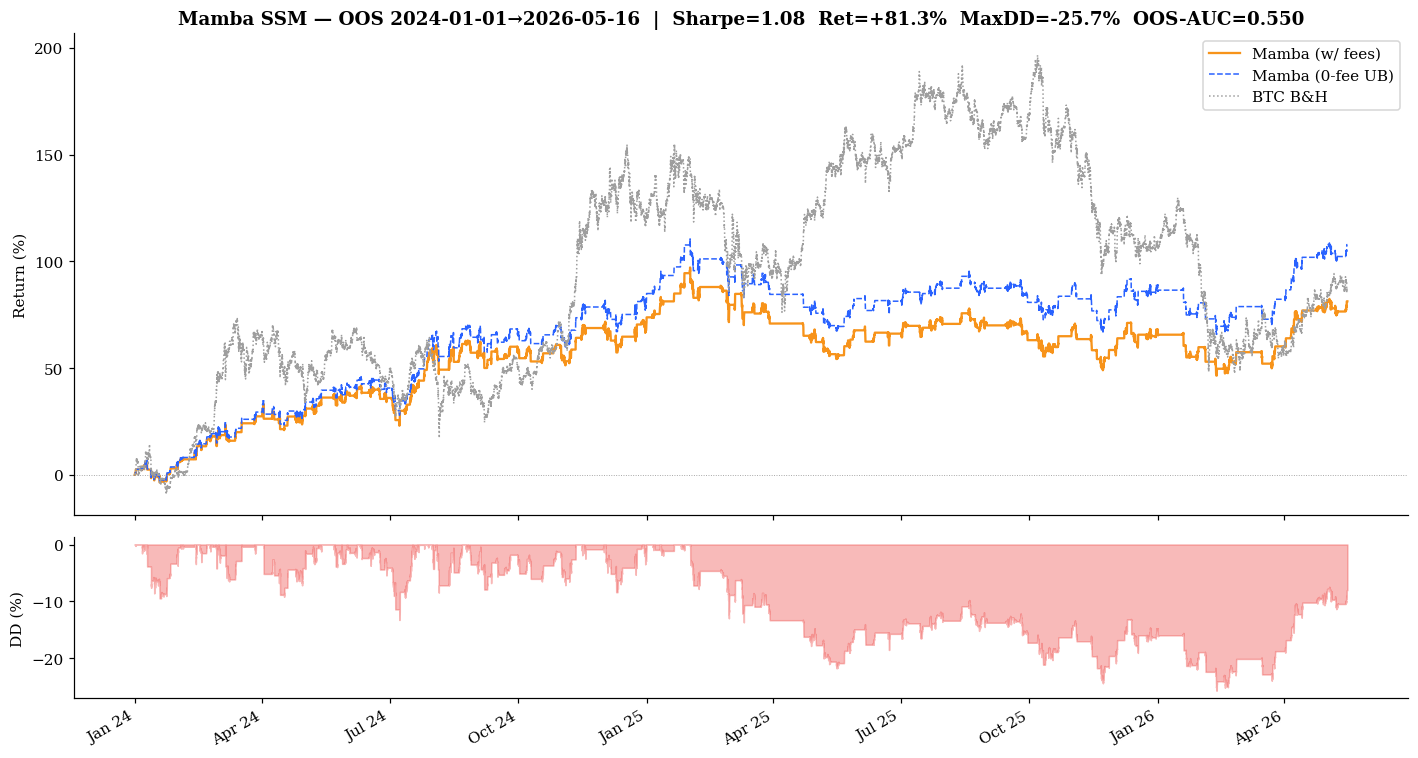

In [16]:
# Equity + drawdown
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(13,7),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100,color=ACCENT,lw=1.5,label='Mamba (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100,color=BLUE,lw=1.0,ls='--',label='Mamba (0-fee UB)')
ax1.plot(o_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
ax1.axhline(0,color=GREY,lw=0.6,ls=':')
ax1.set_ylabel('Return (%)'); ax1.legend()
ax1.set_title(f'Mamba SSM — OOS {OOS_START.date()}→{o_idx[-1].date()}  |  '
    f'Sharpe={_sharpe(eq_fees):.2f}  Ret={eq_fees[-1]-1:+.1%}  MaxDD={_maxdd(eq_fees):.1%}  '
    f'OOS-AUC={auc_oos:.3f}', fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_equity_drawdown.png'); plt.show()

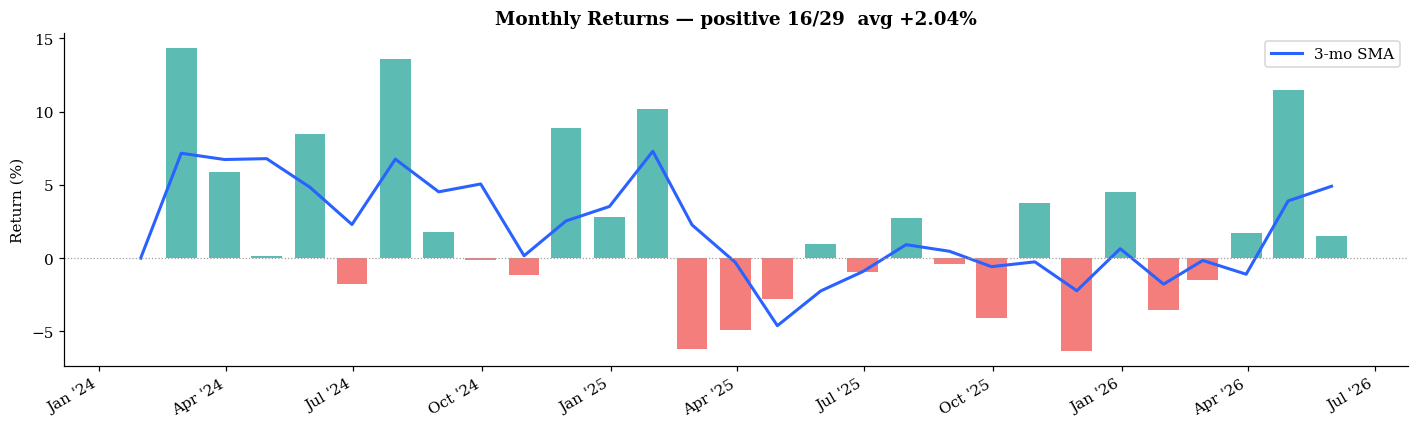

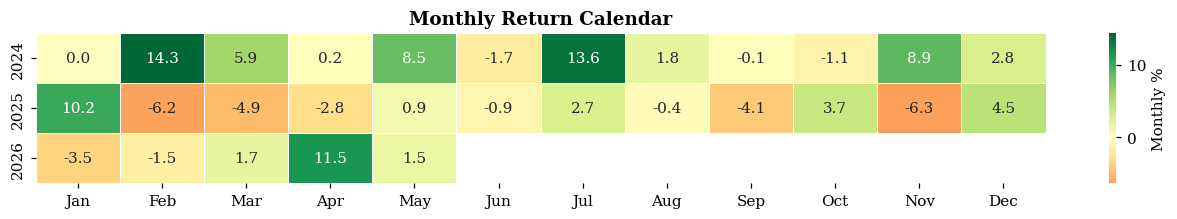

In [17]:
# Monthly returns + heatmap
import calendar
eqs=pd.Series(eq_fees,index=o_idx); mret=eqs.resample('ME').last().pct_change().fillna(0)*100
fig,ax=plt.subplots(figsize=(13,4))
ax.bar(mret.index,mret.values,color=[GREEN if r>=0 else RED for r in mret],width=22,alpha=0.75)
ax.plot(mret.index,mret.rolling(3,min_periods=1).mean(),color=BLUE,lw=2,label='3-mo SMA')
ax.axhline(0,color=GREY,lw=0.8,ls=':'); ax.set_ylabel('Return (%)'); ax.legend()
ax.set_title(f'Monthly Returns — positive {int((mret>0).sum())}/{len(mret)}  '
             f'avg {mret.mean():+.2f}%', fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'02_monthly_returns.png'); plt.show()

cal=mret.to_frame('r'); cal['y']=cal.index.year; cal['m']=cal.index.month
piv=cal.pivot(index='y',columns='m',values='r'); piv.columns=[calendar.month_abbr[m] for m in piv.columns]
fig,ax=plt.subplots(figsize=(12,max(2,len(piv)*0.7)))
sns.heatmap(piv,ax=ax,cmap='RdYlGn',center=0,annot=True,fmt='.1f',linewidths=0.5,
            cbar_kws={'label':'Monthly %'}); ax.set_title('Monthly Return Calendar',fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel(''); fig.tight_layout()
fig.savefig(ARTS_DIR/'03_monthly_heatmap.png'); plt.show()

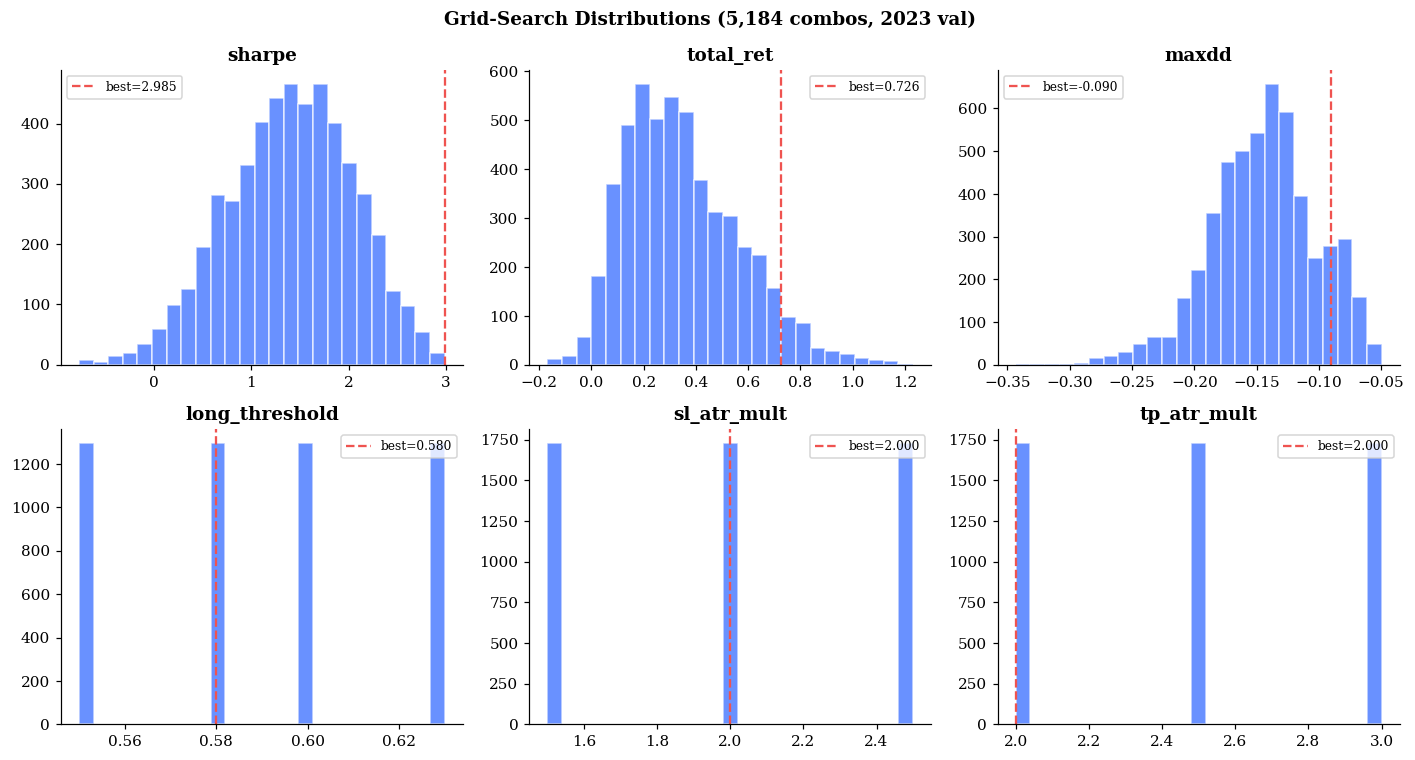

In [18]:
# Grid-search distributions
fig,axes=plt.subplots(2,3,figsize=(13,7)); axes=axes.ravel()
for ax,col in zip(axes,['sharpe','total_ret','maxdd','long_threshold','sl_atr_mult','tp_atr_mult']):
    ax.hist(grid_df[col].dropna(),bins=25,color=BLUE,alpha=0.7,edgecolor='white')
    ax.axvline(grid_df.iloc[0][col],color=RED,ls='--',lw=1.5,label=f'best={grid_df.iloc[0][col]:.3f}')
    ax.set_title(col,fontweight='bold'); ax.legend(fontsize=8)
fig.suptitle(f'Grid-Search Distributions ({len(grid_df):,} combos, 2023 val)',fontweight='bold')
fig.tight_layout(); fig.savefig(ARTS_DIR/'04_grid_distributions.png'); plt.show()

perm-imp:   0%|          | 0/39 [00:00<?, ?it/s]

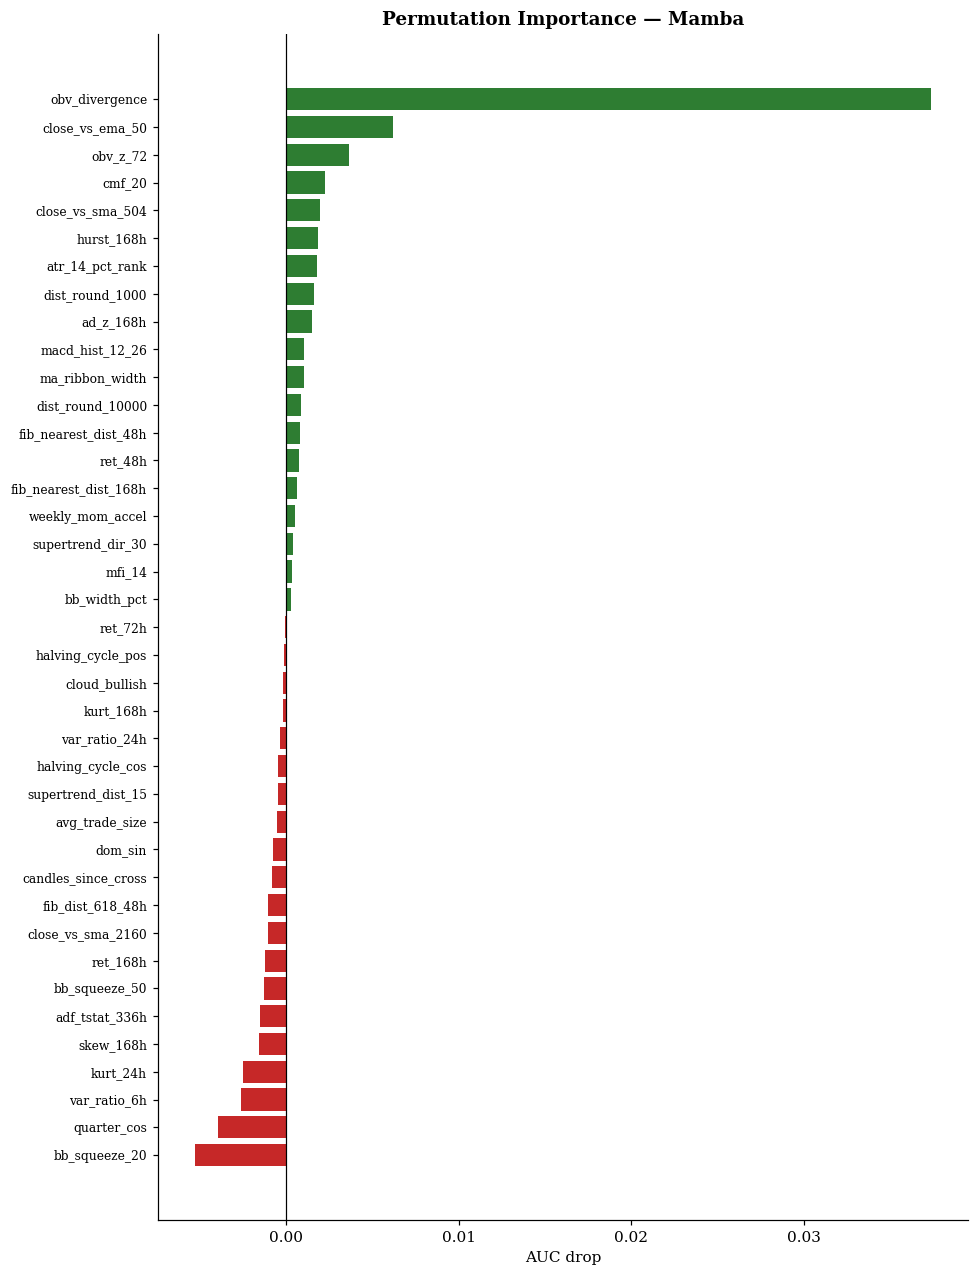

In [19]:
# Permutation importance on last fold's val window (uses best_model + last_qt)
PERM={}
try:
    vl_ts=(df.index<anchors[-1]) if len(anchors)>1 else (df.index<OOS_START)
    vrows=np.where(vl_ts)[0][-4000:]
    Xs=last_qt.transform(np.nan_to_num(df[FEATS].values.astype(np.float32)))
    Xv=np.stack([Xs[e-SEQ_LEN+1:e+1] for e in vrows if e>=SEQ_LEN-1]).astype(np.float32)
    yv=y_all[[e for e in vrows if e>=SEQ_LEN-1]]
    Xv_t=torch.from_numpy(Xv).to(DEVICE); best_model.eval()
    def _auc(X):
        with torch.no_grad():
            p=torch.cat([torch.softmax(best_model(c),-1)[:,1].cpu() for c in torch.split(X,2048)]).numpy()
        return roc_auc_score(yv,p)
    base=_auc(Xv_t)
    for f in tqdm(FEATS,desc='perm-imp'):
        d=[]
        for _ in range(2):
            Xp=Xv_t.clone(); idx=torch.randperm(Xp.shape[0]); Xp[:,:,F_IDX[f]]=Xp[idx,:,F_IDX[f]]
            d.append(base-_auc(Xp))
        PERM[f]=float(np.mean(d))
    sf=sorted(PERM,key=PERM.get,reverse=True)
    fig,ax=plt.subplots(figsize=(9,max(5,len(sf)*0.3)))
    ax.barh(range(len(sf)),[PERM[f] for f in sf],
            color=['#2E7D32' if PERM[f]>0 else '#C62828' for f in sf])
    ax.set_yticks(range(len(sf))); ax.set_yticklabels(sf,fontsize=8); ax.invert_yaxis()
    ax.axvline(0,color='k',lw=0.8); ax.set_xlabel('AUC drop')
    ax.set_title('Permutation Importance — Mamba',fontweight='bold')
    fig.tight_layout(); fig.savefig(ARTS_DIR/'05_feature_importance.png'); plt.show()
except Exception as e:
    print('perm-imp skipped:', e)

## 11 · Save artifacts & download

In [20]:
def _metrics(eq,t,label):
    wr=float((t['net']>0).mean()) if len(t) else 0.
    return {'label':label,'n_trades':len(t),
            'n_long':int((t['direction']=='long').sum()) if len(t) else 0,
            'n_short':int((t['direction']=='short').sum()) if len(t) else 0,
            'win_rate':round(wr,4),'total_ret':round(float(eq[-1]-1),4),
            'sharpe':round(_sharpe(eq),4),'maxdd':round(_maxdd(eq),4)}

results={
    'notebook':'03_mamba_colab_a100','created':pd.Timestamp.now().isoformat(),
    'device':str(DEVICE),
    'architecture':{'d_model':D_MODEL,'d_state':D_STATE,'n_layers':N_LAYERS,
                    'seq_len':SEQ_LEN,'batch':BATCH,'epochs':EPOCHS},
    'wfo':{'pred_start':str(PRED_START.date()),'oos_start':str(OOS_START.date()),
           'retrain_months':RETRAIN_MONTHS,'folds':fold_log},
    'target':LABEL_COL,'n_features':len(FEATS),'selected_features':FEATS,
    'oos_auc':round(float(auc_oos),4),
    'best_params':BEST,'val_sharpe':round(float(grid_df.iloc[0]['sharpe']),4),
    'backtest_wfees':_metrics(eq_fees,TF,'w_fees'),
    'backtest_0fee':_metrics(eq_0fee,T0,'0_fee'),
    'monthly':{'mean_pct':round(float(mret.mean()),3),'median_pct':round(float(mret.median()),3),
               'positive_months':int((mret>0).sum()),'total_months':int(len(mret))},
    'permutation_importance':PERM if 'PERM' in dir() else {},
}
with open(ARTS_DIR/'results.json','w') as f: json.dump(results,f,indent=2,default=str)
TF.to_csv(ARTS_DIR/'trades_wfees.csv',index=False)
print(json.dumps(results,indent=2)[:1200])

# zip + download
zp='/content/mamba_artifacts.zip'
with zipfile.ZipFile(zp,'w',zipfile.ZIP_DEFLATED) as z:
    for p in ARTS_DIR.iterdir(): z.write(p,p.name)
print('\nZipped →',zp)
try:
    from google.colab import files; files.download(zp)
except Exception as e:
    print('(manual download:', zp, ')')

{
  "notebook": "03_mamba_colab_a100",
  "created": "2026-06-06T18:44:23.178492",
  "device": "cuda",
  "architecture": {
    "d_model": 64,
    "d_state": 16,
    "n_layers": 2,
    "seq_len": 24,
    "batch": 1024,
    "epochs": 40
  },
  "wfo": {
    "pred_start": "2023-01-01",
    "oos_start": "2024-01-01",
    "retrain_months": 6,
    "folds": [
      {
        "fold": 0,
        "train_end": "2022-12-31",
        "oos": "2023-01-01\u21922023-07-01",
        "val_auc": 0.5651,
        "ep": 27
      },
      {
        "fold": 1,
        "train_end": "2023-06-30",
        "oos": "2023-07-01\u21922024-01-01",
        "val_auc": 0.568,
        "ep": 29
      },
      {
        "fold": 2,
        "train_end": "2023-12-31",
        "oos": "2024-01-01\u21922024-07-01",
        "val_auc": 0.5593,
        "ep": 35
      },
      {
        "fold": 3,
        "train_end": "2024-06-30",
        "oos": "2024-07-01\u21922025-01-01",
        "val_auc": 0.5576,
        "ep": 27
      },
      {


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>